# 02 · Target Prioritisation
**Input:** `data/processed/dea_results.csv` (from notebook 01)

Runs the three-step target prioritisation pipeline:

| Step | What happens |
|------|-------------|
| P1 · PPI network | STRING API → NetworkX → composite hub score |
| P2 · Survival filter | TCGA-LIHC KM + Cox → survival-significant genes |
| P3 · Drug–gene interactions | DGIdb / ChEMBL / OpenTargets → scored edge list |

**Output:** `results/tables/dgi_edges_gnn.csv` — input for notebook 03 (GNN)


## Setup

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start):
    for p in [start, *start.parents]:
        if (p / "paths.py").exists():
            return p
    raise FileNotFoundError("paths.py not found — run: python scripts/data_download.py")

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "scripts"))

from paths import REPO_ROOT, RAW_DIR, PROC_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR, REPORTS_DIR
print(f"Repo root : {REPO_ROOT}")
print(f"Raw data  : {RAW_DIR}")
print(f"Processed : {PROC_DIR}")

Repo root : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD
Raw data  : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\data\raw
Processed : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\data\processed


In [9]:
from utils.ppi_functions import load_dea, query_string, build_and_score, export_ppi
from utils.survival_functions import (load_gene_list, fetch_tcga_lihc, simulate_tcga,
                                      run_survival, filter_survivors, export_survival)
from utils.dgi_functions import (load_dgi_inputs, collect_interactions,
                                      build_dgi_dataframe, build_gnn_edge_list,
                                      plot_dgi_dashboard)
from utils import plot_ppi_network, plot_km_grid, plot_cox_forest
import matplotlib.pyplot as plt
%matplotlib inline
print("Imports OK")

Imports OK


In [4]:
# ── Configuration — edit here if needed ──────────────────────────────────────
# P1 — PPI
STRING_SCORE  = 400    # 400=medium, 700=high confidence
LOG2FC_THRESH = 1.0
PADJ_THRESH   = 0.05
TOP_VIZ_NODES = 80

# P2 — Survival
KM_P_THRESH   = 0.05
COX_P_THRESH  = 0.05
HR_MIN        = 0.8
HR_MAX        = 1.2
TOP_KM        = 12
RANDOM_SEED   = 42

# P3 — Database selection (set to False to skip a source)
USE_DGIDB       = True
USE_CHEMBL      = False
USE_OPENTARGETS = False
USE_CURATED     = True    # fills gaps automatically

# P3 — Composite score weights (must sum to 1.0)
W = {"interaction": 0.35, "publications": 0.20,
     "phase": 0.20, "approved": 0.15, "hub": 0.10}

print("Configuration loaded")

Configuration loaded


---
## P1 · PPI Network & Hub Genes

In [5]:
sig, gene_list = load_dea(PROC_DIR / "dea_results.csv",
                          log2fc_thresh=LOG2FC_THRESH,
                          padj_thresh=PADJ_THRESH)
sig.head()

DEGs loaded    : 1385
  Upregulated  : 335
  Downregulated: 1050
  Unique genes : 1385


,gene,log2FC,adj_pvalue,regulation
0,RPS26,1.991955,7.295115e-149,up
1,XIST,31.180847,2.625168e-118,up
2,MALAT1,1.089554,3.200503e-93,up
3,CREM,2.918553,7.829163e-81,up
4,JUND,1.322786,5.349000e-73,up


In [6]:
edges_df = query_string(gene_list, string_score=STRING_SCORE)

  Batch 1: 500 genes... → 2186 interactions
  Batch 2: 500 genes... → 1574 interactions
  Batch 3: 385 genes... → 3999 interactions

Unique interactions: 7759


In [7]:
G, hub_df = build_and_score(sig, edges_df)
hub_df[["gene","degree","hub_score","regulation"]].head(10)

Nodes : 1162
Edges : 7551


,gene,degree,hub_score,regulation
0,GAPDH,135,0.926926,down
1,CD4,110,0.763489,down
2,IL1B,113,0.750842,down
3,ALB,97,0.691624,down
4,APOE,94,0.649482,down
5,MMP9,84,0.601919,down
6,CTSS,85,0.587974,down
7,CSF1R,77,0.574566,down
8,CXCL8,74,0.568251,down
9,CD68,77,0.567907,down


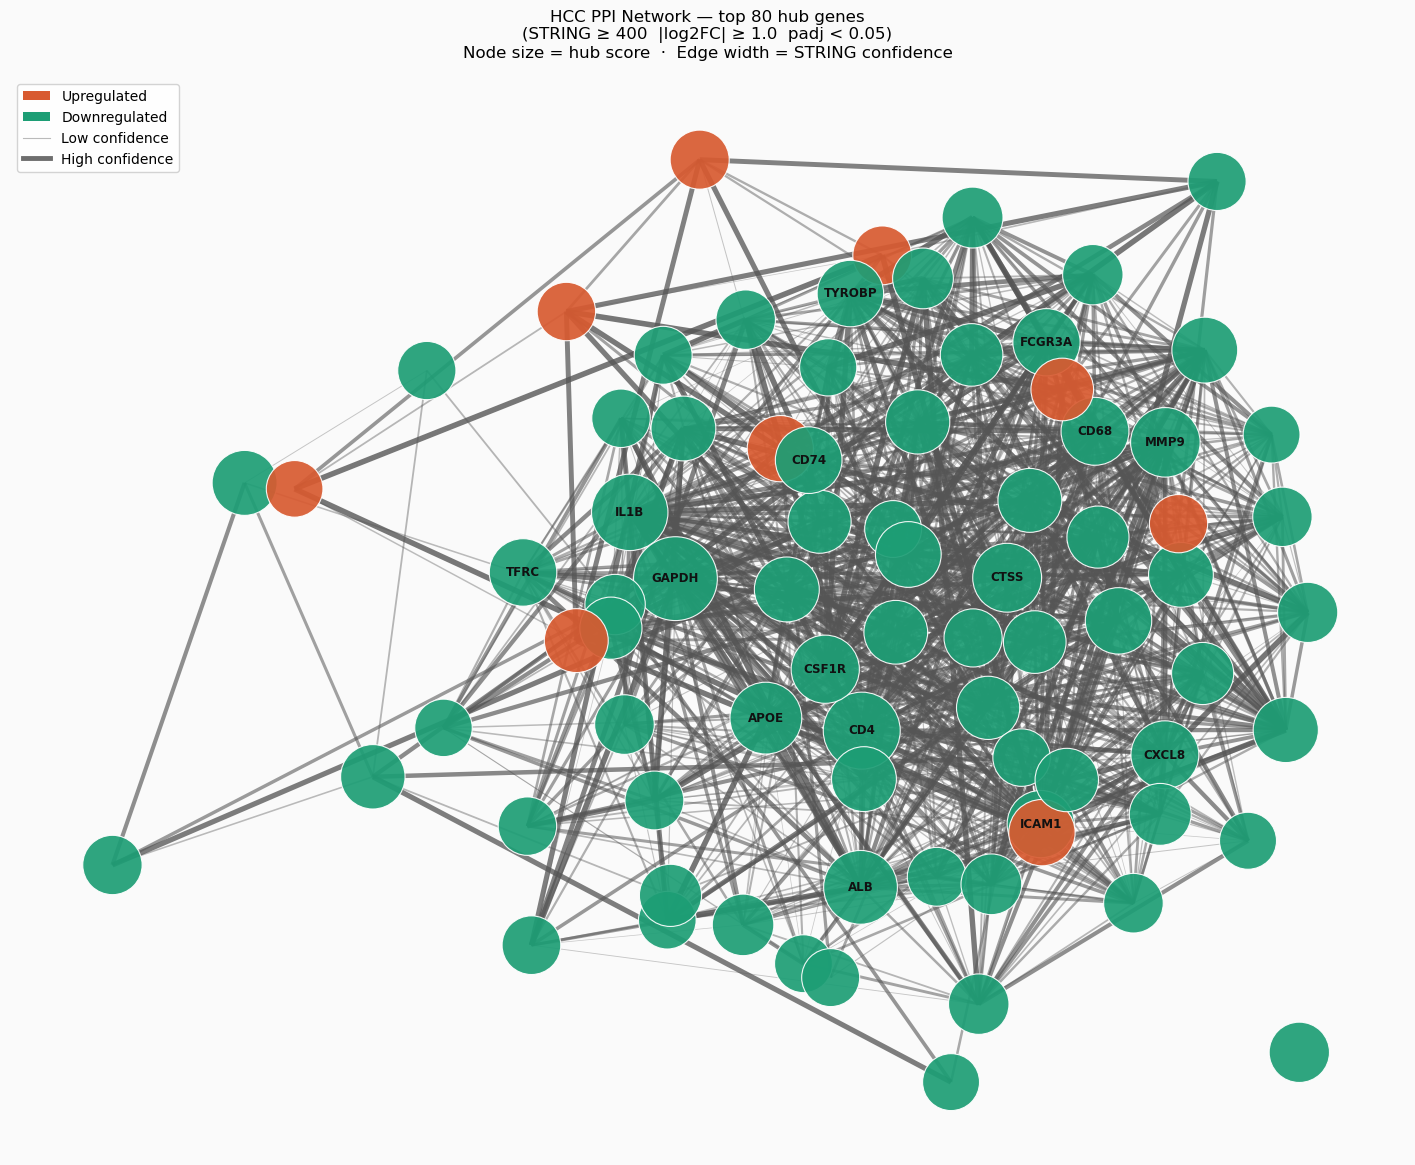

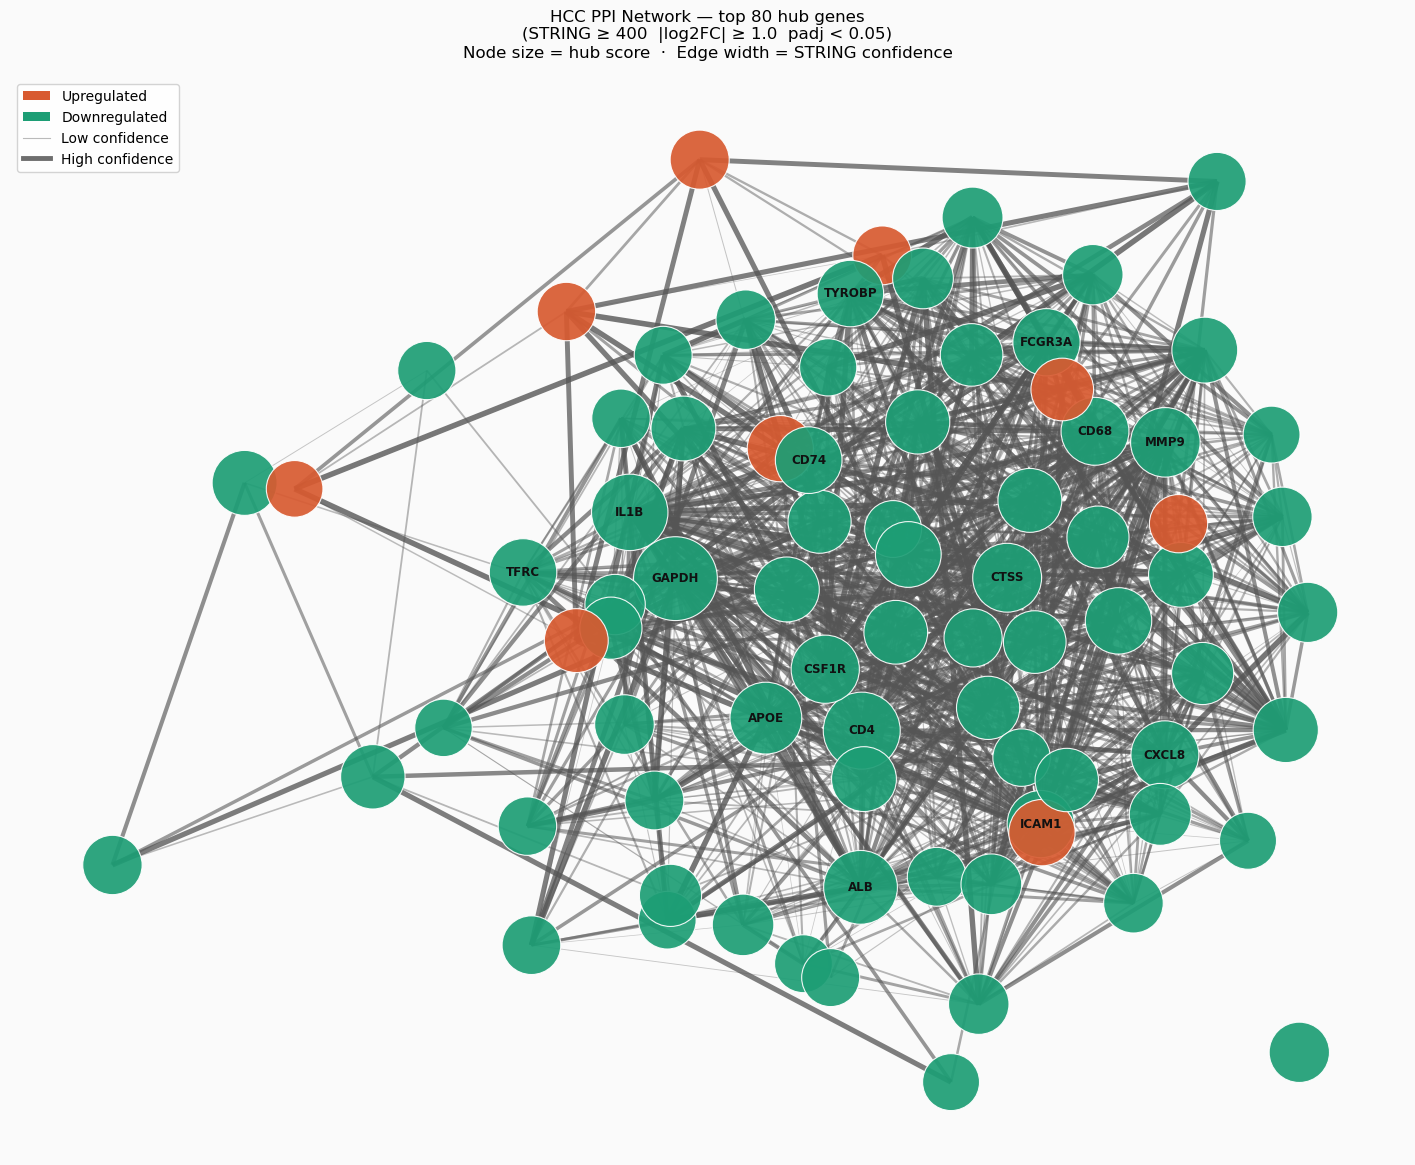

In [10]:
fig, _ = plot_ppi_network(G, hub_df, top_nodes=TOP_VIZ_NODES,
                          string_score=STRING_SCORE,
                          log2fc_thresh=LOG2FC_THRESH,
                          padj_thresh=PADJ_THRESH)
fig.savefig(FIGURES_DIR / "ppi_network.png", dpi=200, bbox_inches="tight")
plt.show()

In [11]:
export_ppi(hub_df, G, edges_df, TABLES_DIR)

Saved: hub_genes.csv            (1162 genes)
Saved: ppi_edges_cytoscape.csv  (7551 edges)

Top 5 hub genes: ['GAPDH', 'CD4', 'IL1B', 'ALB', 'APOE']


---
## P2 · Survival Filter

In [12]:
sig, gene_list, hub_score_map = load_gene_list(
    PROC_DIR / "dea_results.csv",
    hub_path=TABLES_DIR / "hub_genes.csv",
)

DEGs       : 1385
Hub scores : 1162 genes loaded


In [13]:
merged, is_sim = fetch_tcga_lihc()
if is_sim:
    merged = simulate_tcga(gene_list, random_seed=RANDOM_SEED)

avail = [g for g in gene_list if g in merged.columns]
print(f"Genes with expression: {len(avail)}/{len(gene_list)}")
print(f"Data source: {'⚠ SIMULATED' if is_sim else '✓ TCGA-LIHC'}")

  ✗ Download failed: 'DataFrame' object has no attribute 'str'
  → Will use simulated data
Genes with expression: 1385/1385
Data source: ⚠ SIMULATED


In [14]:
surv_raw = run_survival(gene_list, merged)
surv_df, surv_filtered = filter_survivors(
    surv_raw, sig,
    km_p=KM_P_THRESH, cox_p=COX_P_THRESH,
    hr_min=HR_MIN, hr_max=HR_MAX,
)
surv_filtered[["gene","HR","prognosis","logrank_p"]].head(10)

Testing 1385 genes...
  [50/1385]
  [100/1385]
  [150/1385]
  [200/1385]
  [250/1385]
  [300/1385]
  [350/1385]
  [400/1385]
  [450/1385]
  [500/1385]
  [550/1385]
  [600/1385]
  [650/1385]
  [700/1385]
  [750/1385]
  [800/1385]
  [850/1385]
  [900/1385]
  [950/1385]
  [1000/1385]
  [1050/1385]
  [1100/1385]
  [1150/1385]
  [1200/1385]
  [1250/1385]
  [1300/1385]
  [1350/1385]
Genes analysed         : 1385
KM significant         : 72
Passing all filters    : 3
  Protective (HR<1)    : 0
  Risk (HR>1)          : 3


,gene,HR,prognosis,logrank_p
1,XIST,1.231499,risk,0.000122
20,APOC1,1.201678,risk,0.016451
40,DRAM2,1.200254,risk,0.027678


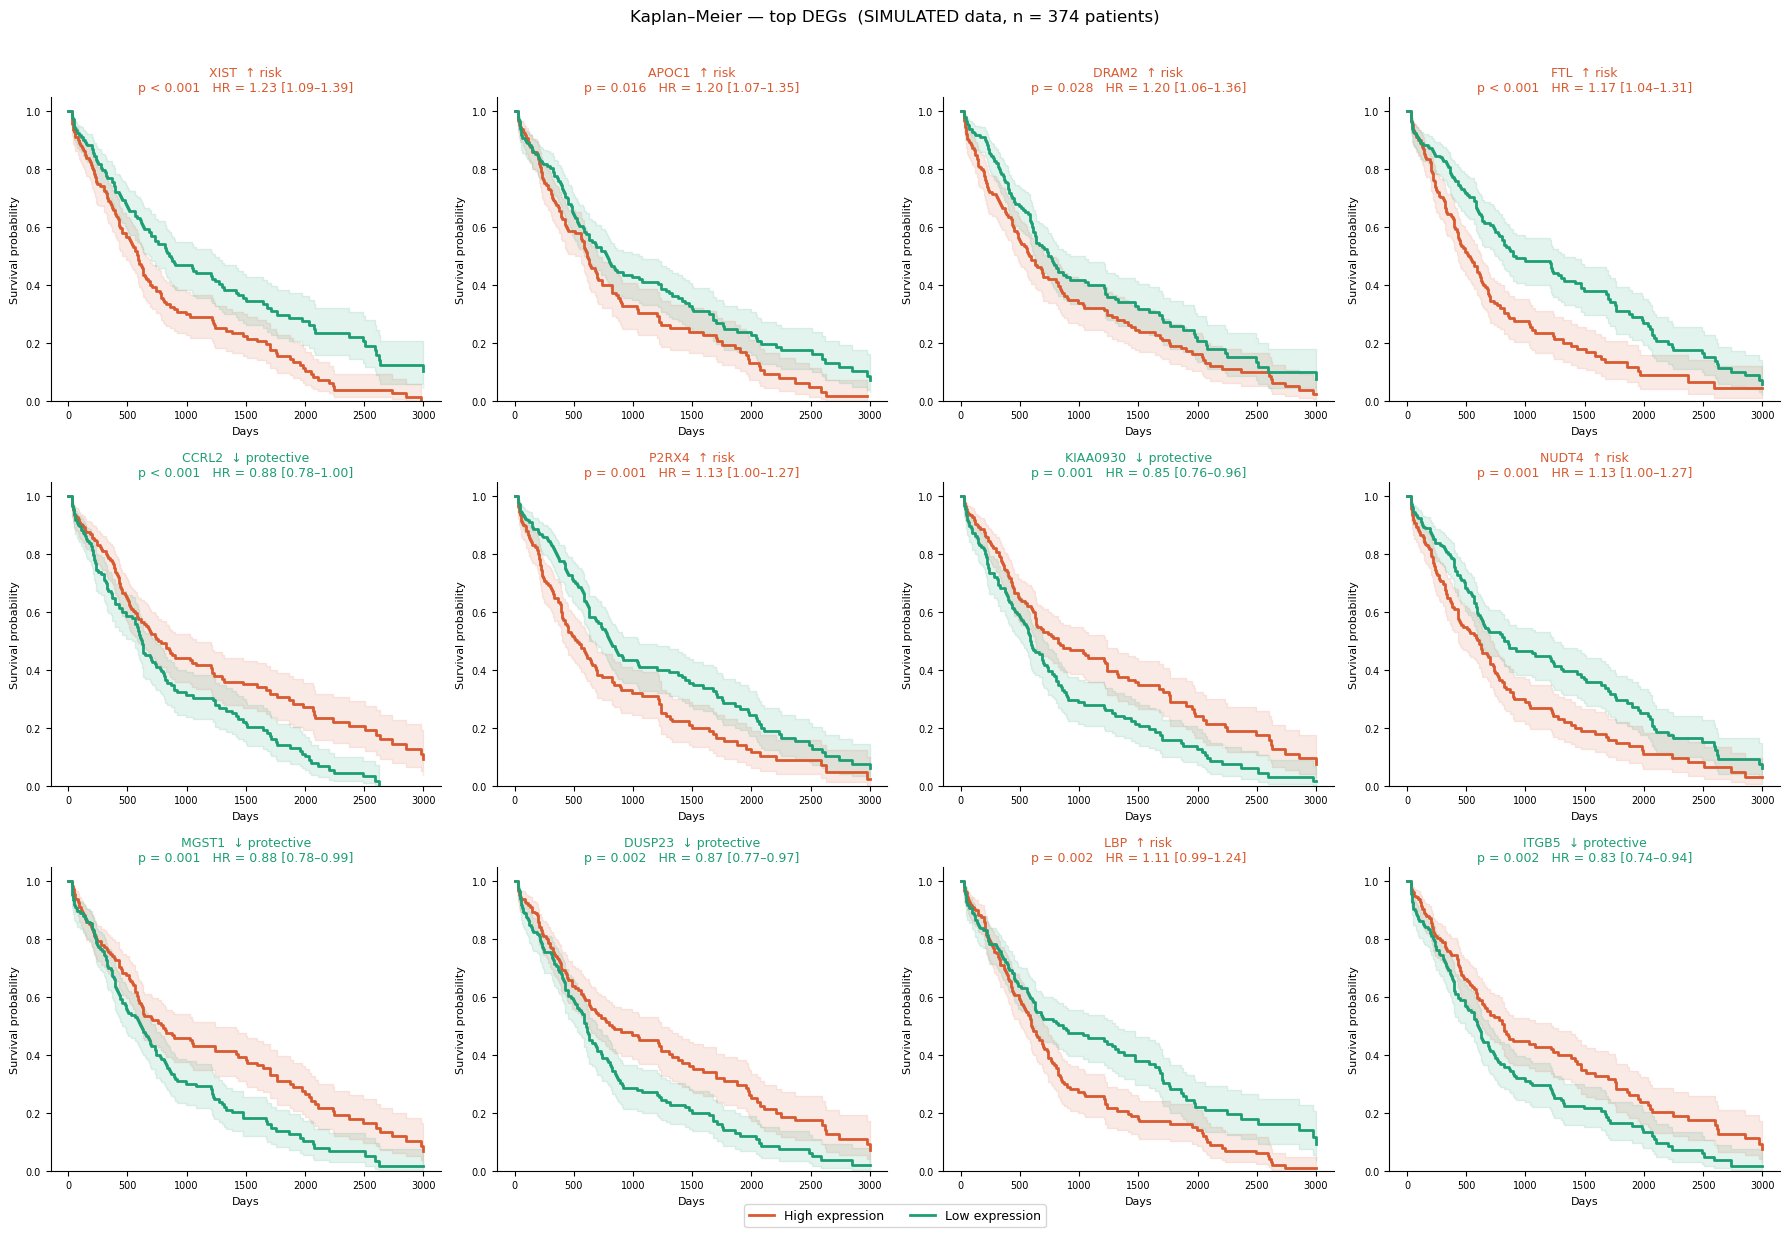

In [15]:
top_genes = surv_filtered.head(TOP_KM).gene.tolist()
if len(top_genes) < TOP_KM:
    top_genes += (surv_df[~surv_df.gene.isin(top_genes)]
                  .head(TOP_KM - len(top_genes)).gene.tolist())

fig = plot_km_grid(top_genes, surv_df, merged, is_simulated=is_sim)
fig.savefig(FIGURES_DIR / "km_plots.png", dpi=200, bbox_inches="tight")
plt.show()

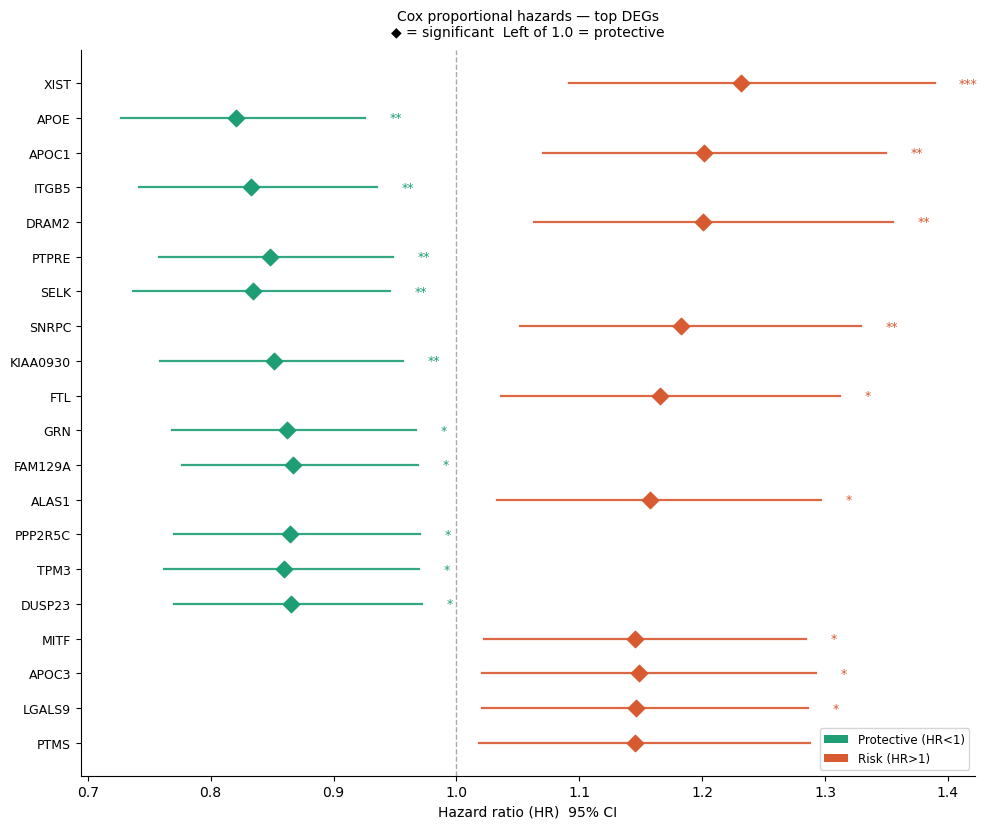

In [16]:
fig, _ = plot_cox_forest(surv_df, top_n=20, cox_p_thresh=COX_P_THRESH)
fig.savefig(FIGURES_DIR / "cox_forest_plot.png", dpi=200, bbox_inches="tight")
plt.show()

In [17]:
export_survival(surv_df, surv_filtered, TABLES_DIR)

Saved: survival_results.csv          (1385 genes)
Saved: survival_filtered_genes.csv   (3 genes  →  GNN input)


---
## P3 · Drug–Gene Interactions

In [18]:
print("Database selection:")
for name, flag in [("DGIdb", USE_DGIDB), ("ChEMBL", USE_CHEMBL),
                   ("OpenTargets", USE_OPENTARGETS), ("Curated", USE_CURATED)]:
    print(f"  {name:<14}: {'✓ enabled' if flag else '✗ disabled'}")

Database selection:
  DGIdb         : ✓ enabled
  ChEMBL        : ✗ disabled
  OpenTargets   : ✗ disabled
  Curated       : ✓ enabled


In [19]:
gene_list, hub_score_map, surv_genes = load_dgi_inputs(TABLES_DIR)

Hub genes        : 1162
Survival targets : 3


In [20]:
all_edges, apis_ok = collect_interactions(
    gene_list,
    use_dgidb=USE_DGIDB,
    use_chembl=USE_CHEMBL,
    use_opentargets=USE_OPENTARGETS,
    use_curated=USE_CURATED,
)

Querying DGIdb...
    DGIdb: 8069 interactions returned
  → 8069 interactions
Curated: 6 interactions added for 618 uncovered genes

Sources used    : ['DGIdb']
Raw interactions: 8075


In [21]:
dgi_df = build_dgi_dataframe(all_edges, hub_score_map, surv_genes, W)
dgi_df[["gene","drug","composite_score","approved","clinical_phase","source"]].head(10)

Edges (deduplicated): 8027
Unique genes        : 547
Unique drugs        : 4978
Approved drugs      : 2795


,gene,drug,composite_score,approved,clinical_phase,source
0,TPP1,Cerliponase Alfa,0.7229,True,4,DGIdb
1,IFNGR2,Interferon Gamma-1B,0.6060,True,4,DGIdb
2,NRAS,Trametinib Dimethyl Sulfoxide,0.5923,True,4,DGIdb
3,EML4,Alectinib,0.5864,True,4,DGIdb
4,TYROBP,Sorafenib,0.5828,True,4,OpenTargets
5,EML4,Lorlatinib,0.5776,True,4,DGIdb
6,EML4,Brigatinib,0.5761,True,4,DGIdb
7,EML4,Crizotinib,0.5741,True,4,DGIdb
8,EML4,Ceritinib,0.5727,True,4,DGIdb
9,TYROBP,Regorafenib,0.5301,True,4,ChEMBL


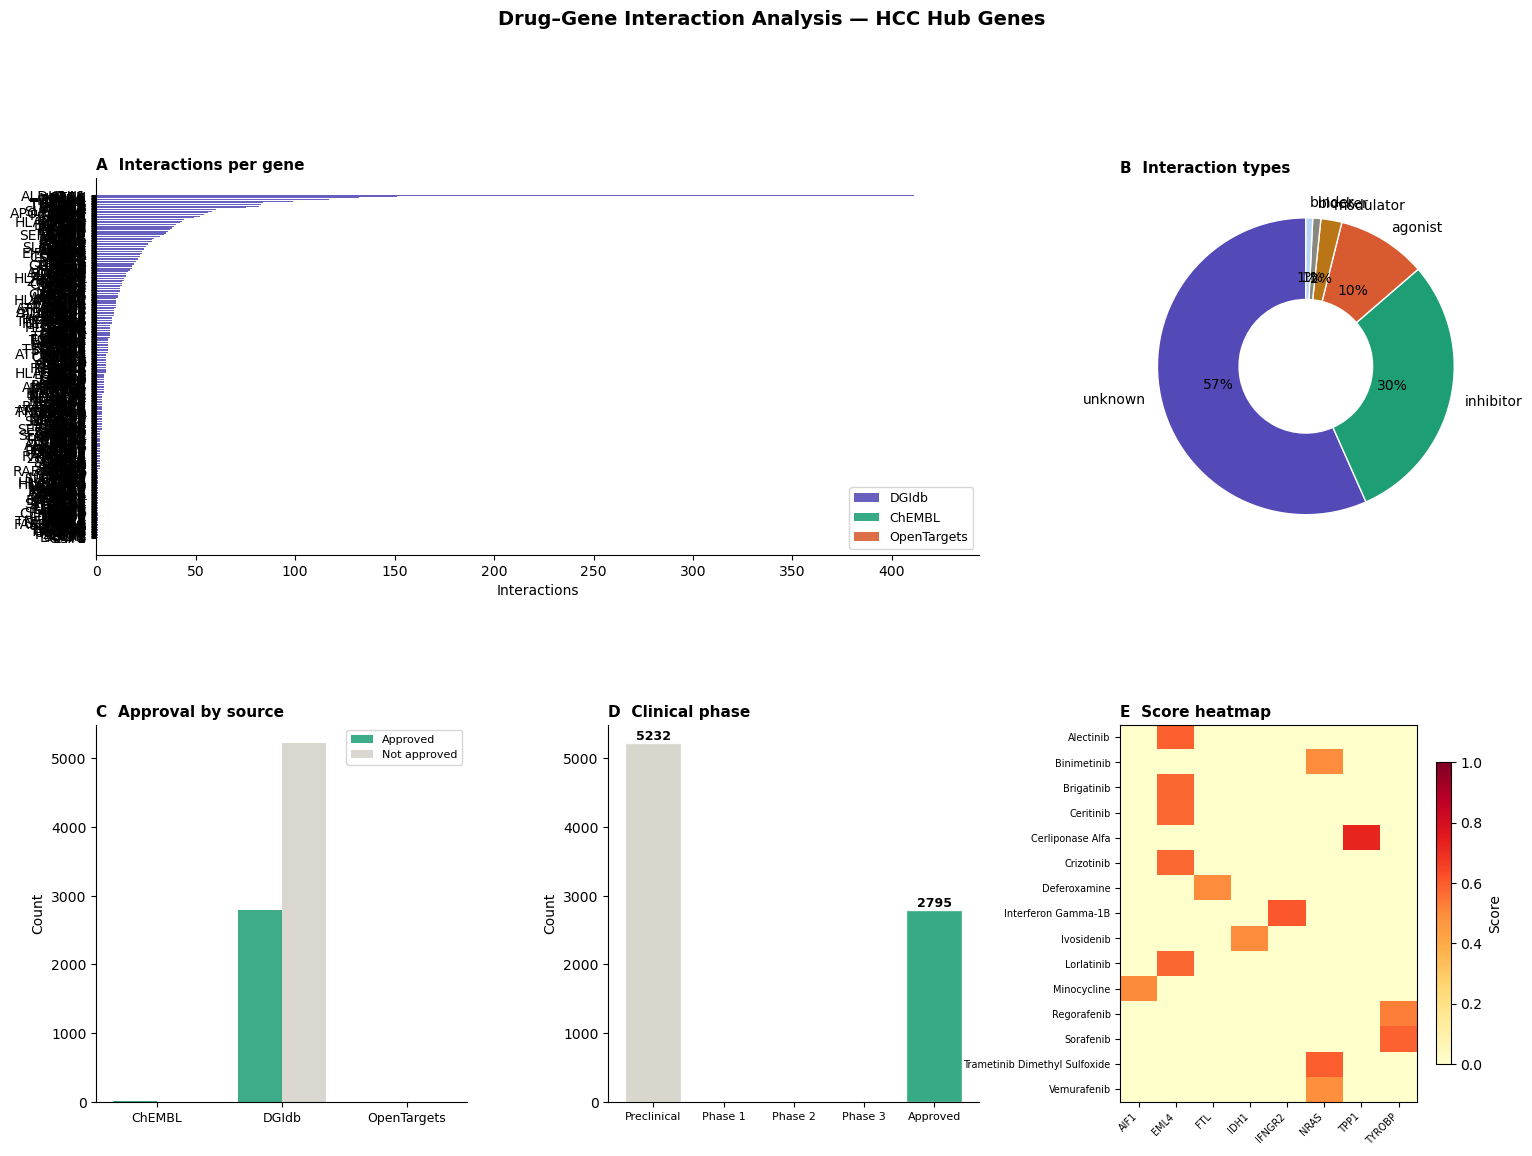

Saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures/dgi_summary_dashboard.png


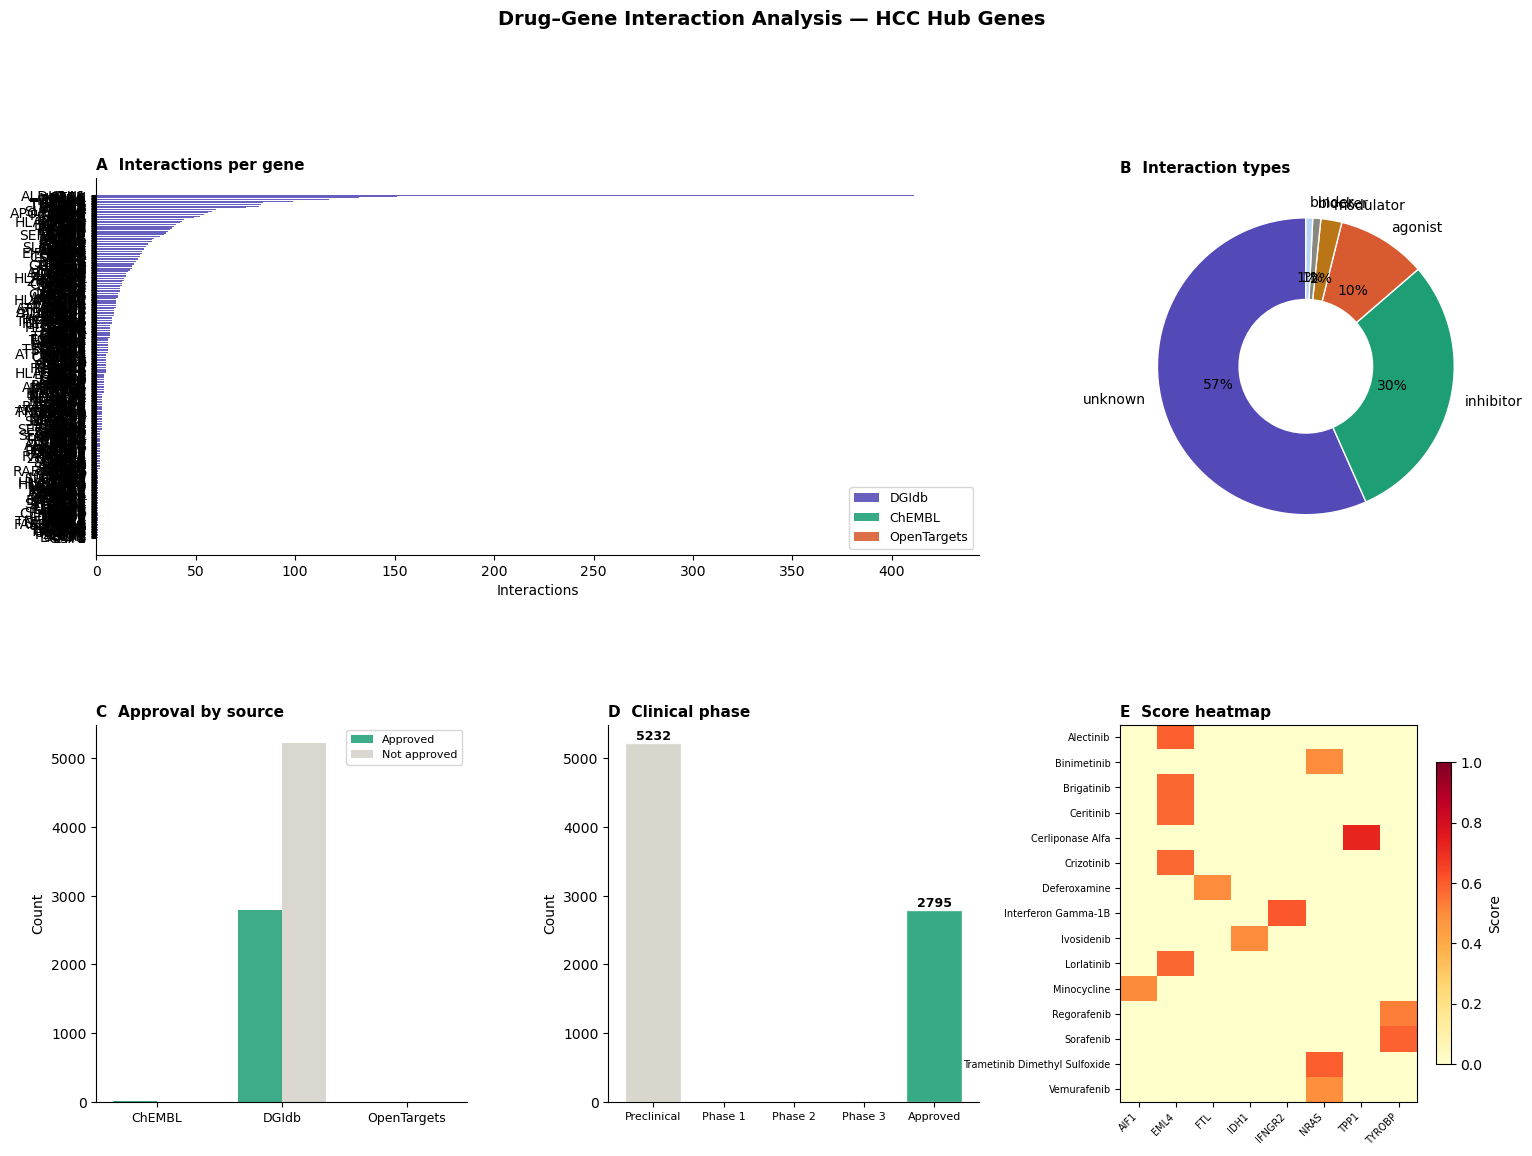

In [22]:
plot_dgi_dashboard(dgi_df, FIGURES_DIR)

In [23]:
gnn_df = build_gnn_edge_list(dgi_df, hub_score_map, surv_genes, TABLES_DIR)

Saved: dgi_edges_gnn.csv
  Edges  : 8027
  Genes  : 547
  Drugs  : 4978
  → Ready for notebook P4 (GNN)


---
## Report
Generates a self-contained HTML summary for biology experts.

In [24]:
from utils.report_functions import generate_target_report

report_path = generate_target_report(
    # P1
    sig=sig, gene_list=gene_list, G=G, hub_df=hub_df, edges_df=edges_df,
    string_score=STRING_SCORE, log2fc_thresh=LOG2FC_THRESH, padj_thresh=PADJ_THRESH,
    # P2
    surv_df=surv_df, surv_filtered=surv_filtered, is_sim=is_sim,
    km_p_thresh=KM_P_THRESH, cox_p_thresh=COX_P_THRESH,
    hr_min=HR_MIN, hr_max=HR_MAX,
    # P3
    dgi_df=dgi_df, apis_ok=apis_ok,
    use_dgidb=USE_DGIDB, use_chembl=USE_CHEMBL,
    use_opentargets=USE_OPENTARGETS, use_curated=USE_CURATED, W=W,
    # paths
    figures_dir=FIGURES_DIR, tables_dir=TABLES_DIR, reports_dir=REPORTS_DIR,
)
print(f"\nOpen in browser: {report_path}")

  Report saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\reports\02_target_prioritisation_report.html

Open in browser: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\reports\02_target_prioritisation_report.html
